In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    'HHS_Unaccompanied_Alien_Children_Program.csv',
    engine='python'
)

In [4]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [5]:
print(df.columns)

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='str')


In [6]:
df.columns = df.columns.str.strip()

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
numeric_cols = [
    'Children in CBP custody',
    'Children in HHS Care',
    'Children transferred out of CBP custody',
    'Children discharged from HHS Care'
]

for col in numeric_cols:
    
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '')
    )

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [9]:
print(df.dtypes)

Date                                               datetime64[us]
Children apprehended and placed in CBP custody*           float64
Children in CBP custody                                   float64
Children transferred out of CBP custody                   float64
Children in HHS Care                                      float64
Children discharged from HHS Care                         float64
dtype: object


In [10]:
df['Total System Load'] = (
    df['Children in CBP custody']
    +
    df['Children in HHS Care']
)

In [11]:
print(df[['Date', 'Total System Load']].head())

        Date  Total System Load
0 2025-12-21             2502.0
1 2025-12-18             2522.0
2 2025-12-17             2512.0
3 2025-12-16             2522.0
4 2025-12-15             2512.0


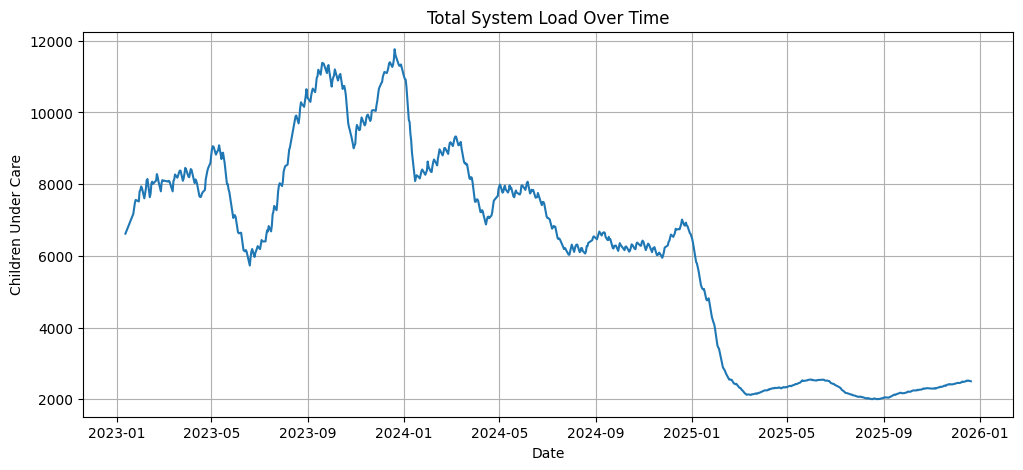

In [12]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Total System Load']
)

plt.title('Total System Load Over Time')

plt.xlabel('Date')

plt.ylabel('Children Under Care')

plt.grid(True)

plt.show()

In [13]:
df['Net Intake Pressure'] = (
    df['Children transferred out of CBP custody']
    -
    df['Children discharged from HHS Care']
)

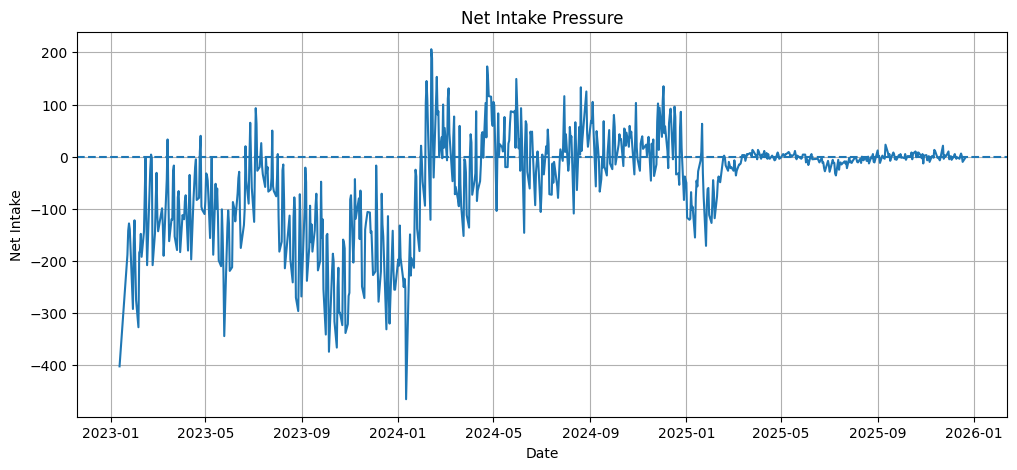

In [14]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Net Intake Pressure']
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Net Intake Pressure')

plt.xlabel('Date')

plt.ylabel('Net Intake')

plt.grid(True)

plt.show()

In [15]:
df['7-Day Avg Load'] = (
    df['Total System Load']
    .rolling(7)
    .mean()
)

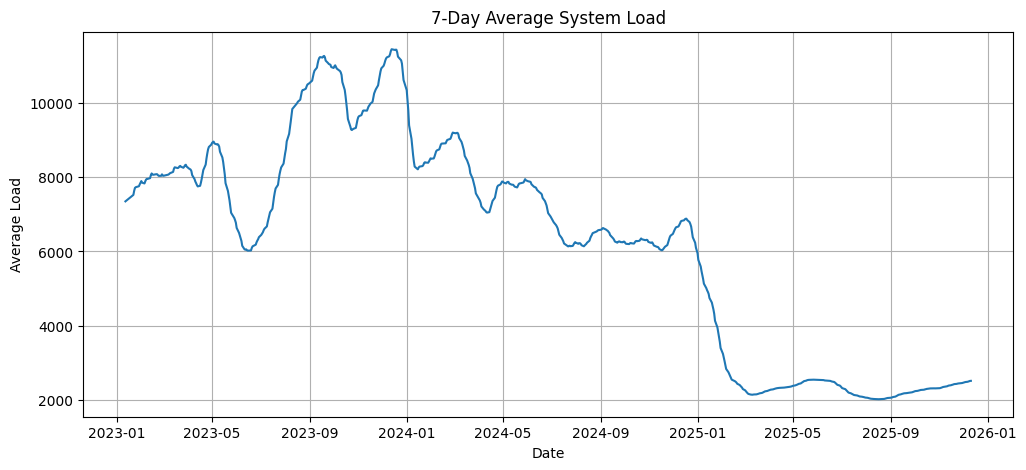

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['7-Day Avg Load']
)

plt.title('7-Day Average System Load')

plt.xlabel('Date')

plt.ylabel('Average Load')

plt.grid(True)

plt.show()

In [17]:
df['14-Day Avg Load'] = (
    df['Total System Load']
    .rolling(14)
    .mean()
)

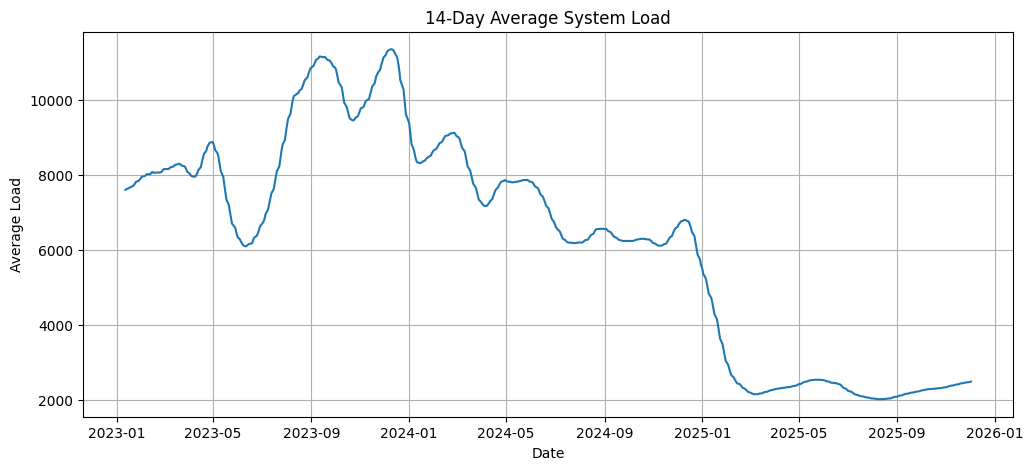

In [18]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['14-Day Avg Load']
)

plt.title('14-Day Average System Load')

plt.xlabel('Date')

plt.ylabel('Average Load')

plt.grid(True)

plt.show()

In [19]:
df['Growth Rate %'] = (
    df['Total System Load']
    .pct_change()
    * 100
)

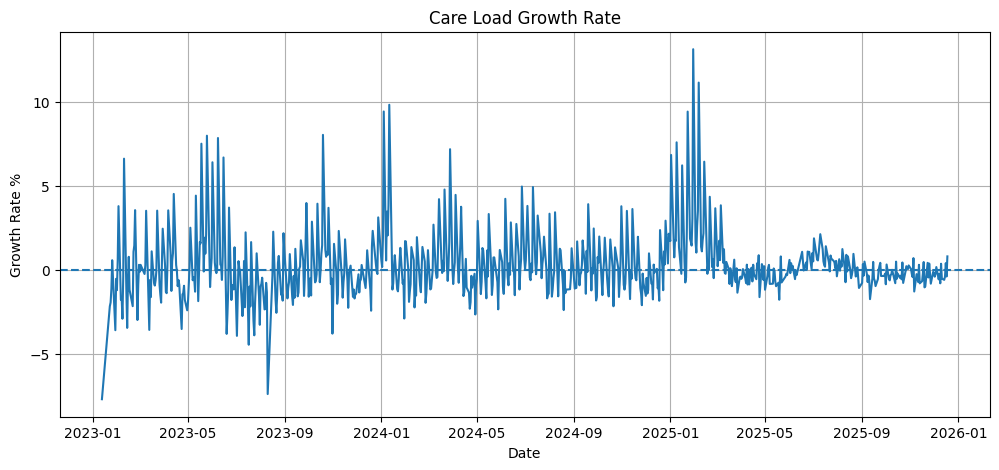

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Growth Rate %']
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Care Load Growth Rate')

plt.xlabel('Date')

plt.ylabel('Growth Rate %')

plt.grid(True)

plt.show()

In [21]:
print("Average Total System Load:",
      df['Total System Load'].mean())

print("Maximum System Load:",
      df['Total System Load'].max())

print("Average Net Intake Pressure:",
      df['Net Intake Pressure'].mean())

print("Maximum Growth Rate:",
      df['Growth Rate %'].max())

Average Total System Load: 6232.769444444444
Maximum System Load: 11762.0
Average Net Intake Pressure: -44.73888888888889
Maximum Growth Rate: 13.124108416547786


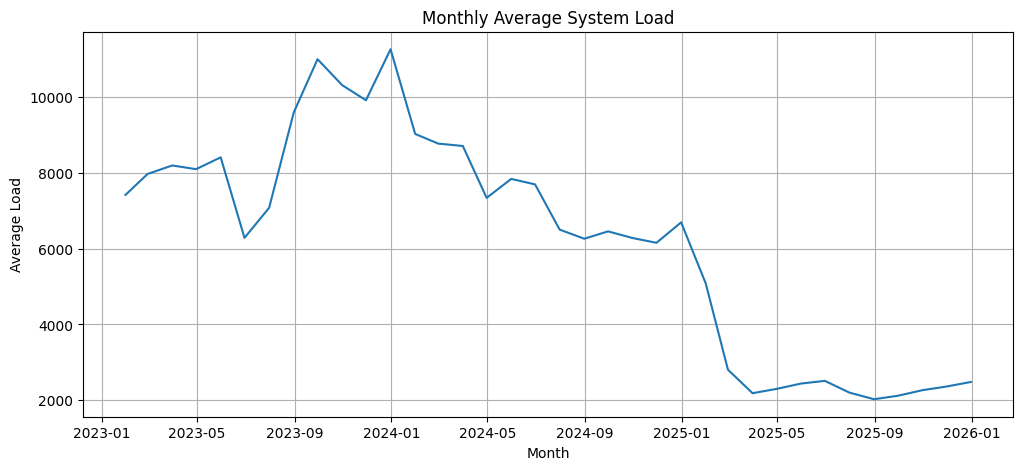

In [23]:
monthly_load = (
    df
    .resample('ME', on='Date')
    ['Total System Load']
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_load.index,
    monthly_load.values
)

plt.title('Monthly Average System Load')

plt.xlabel('Month')

plt.ylabel('Average Load')

plt.grid(True)

plt.show()

In [24]:
print("===== KPI SUMMARY =====")

print("\nAverage Total System Load:")
print(df['Total System Load'].mean())

print("\nMaximum System Load:")
print(df['Total System Load'].max())

print("\nMinimum System Load:")
print(df['Total System Load'].min())

print("\nAverage Net Intake Pressure:")
print(df['Net Intake Pressure'].mean())

print("\nMaximum Growth Rate (%):")
print(df['Growth Rate %'].max())

print("\nMinimum Growth Rate (%):")
print(df['Growth Rate %'].min())

===== KPI SUMMARY =====

Average Total System Load:
6232.769444444444

Maximum System Load:
11762.0

Minimum System Load:
2002.0

Average Net Intake Pressure:
-44.73888888888889

Maximum Growth Rate (%):
13.124108416547786

Minimum Growth Rate (%):
-7.697671175568265


In [25]:
df['Backlog Indicator'] = (
    df['Net Intake Pressure'] > 0
)

In [26]:
print(
    df['Backlog Indicator']
    .value_counts()
)

Backlog Indicator
False    932
True     238
Name: count, dtype: int64


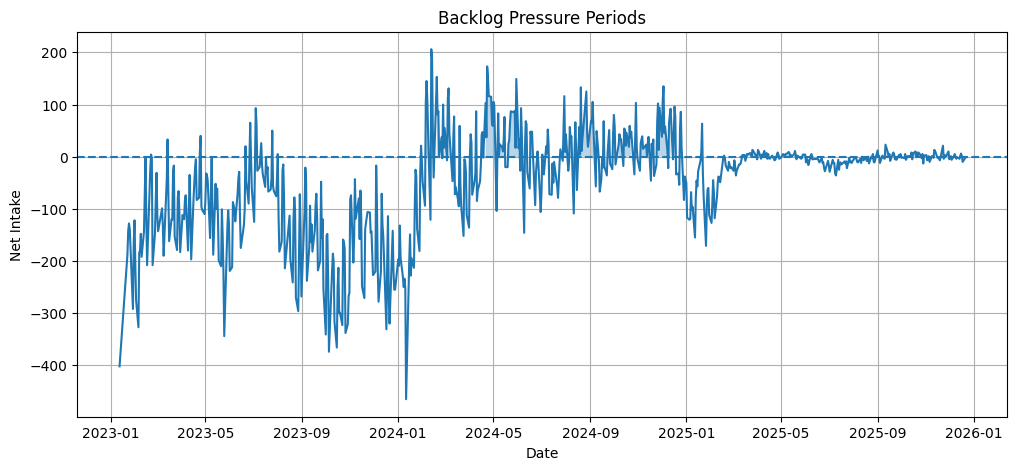

In [27]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Net Intake Pressure']
)

plt.fill_between(
    df['Date'],
    df['Net Intake Pressure'],
    where=df['Net Intake Pressure'] > 0,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Backlog Pressure Periods')

plt.xlabel('Date')

plt.ylabel('Net Intake')

plt.grid(True)

plt.show()

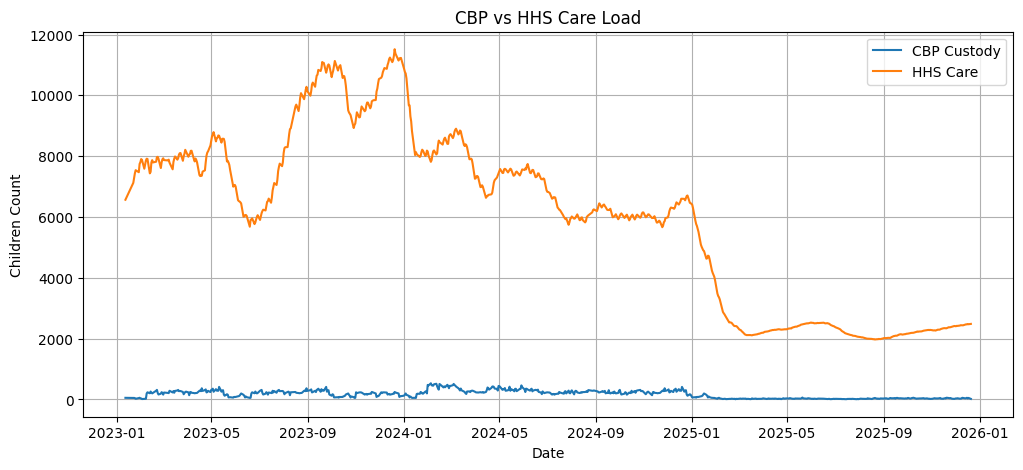

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Children in CBP custody'],
    label='CBP Custody'
)

plt.plot(
    df['Date'],
    df['Children in HHS Care'],
    label='HHS Care'
)

plt.title('CBP vs HHS Care Load')

plt.xlabel('Date')

plt.ylabel('Children Count')

plt.legend()

plt.grid(True)

plt.show()

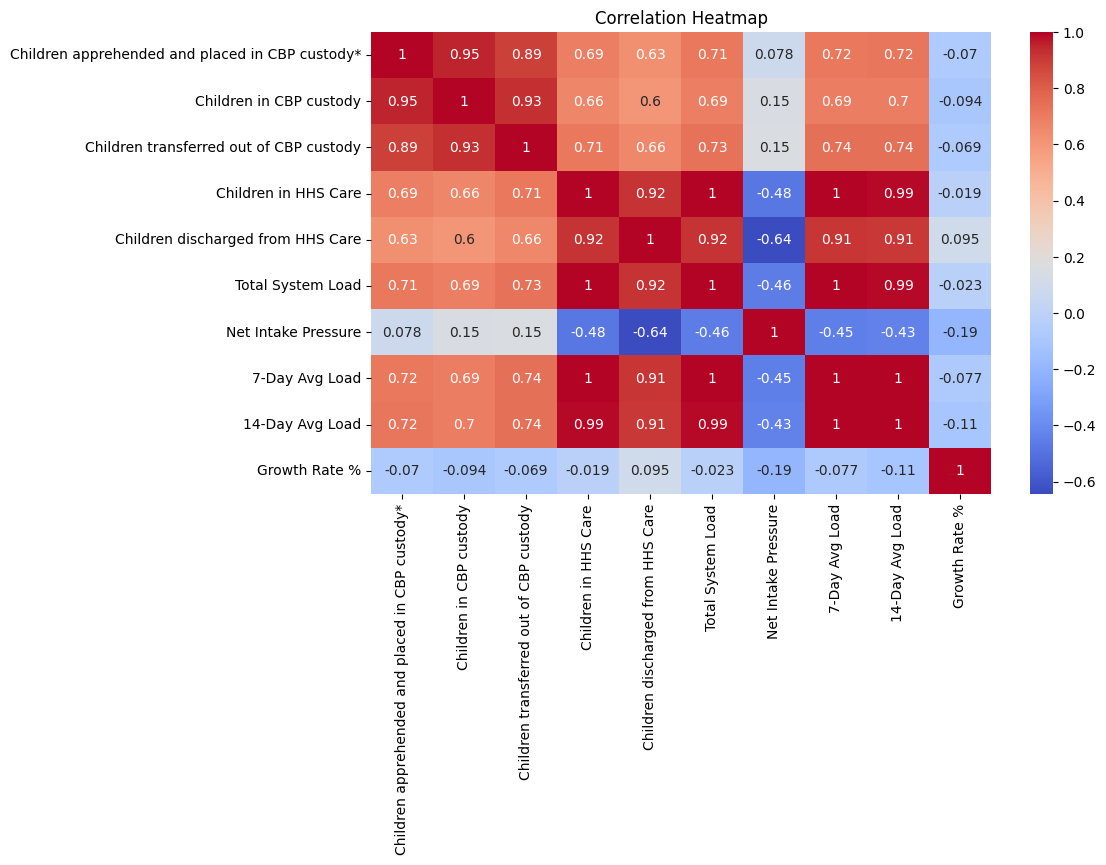

In [29]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [30]:
highest_load = df.loc[
    df['Total System Load'].idxmax()
]

print(highest_load)

Date                                               2023-12-20 00:00:00
Children apprehended and placed in CBP custody*                  136.0
Children in CBP custody                                          246.0
Children transferred out of CBP custody                          123.0
Children in HHS Care                                           11516.0
Children discharged from HHS Care                                390.0
Total System Load                                              11762.0
Net Intake Pressure                                             -267.0
7-Day Avg Load                                            11377.714286
14-Day Avg Load                                           10739.214286
Growth Rate %                                                 1.370335
Backlog Indicator                                                False
Name: 495, dtype: object


In [31]:
lowest_load = df.loc[
    df['Total System Load'].idxmin()
]

print(lowest_load)

Date                                               2025-08-24 00:00:00
Children apprehended and placed in CBP custody*                    4.0
Children in CBP custody                                           21.0
Children transferred out of CBP custody                            5.0
Children in HHS Care                                            1981.0
Children discharged from HHS Care                                  5.0
Total System Load                                               2002.0
Net Intake Pressure                                                0.0
7-Day Avg Load                                                  2020.0
14-Day Avg Load                                                 2040.0
Growth Rate %                                                 -0.39801
Backlog Indicator                                                False
Name: 81, dtype: object


In [32]:
highest_pressure = df.loc[
    df['Net Intake Pressure'].idxmax()
]

print(highest_pressure)

Date                                               2024-02-12 00:00:00
Children apprehended and placed in CBP custody*                  213.0
Children in CBP custody                                          430.0
Children transferred out of CBP custody                          440.0
Children in HHS Care                                            8092.0
Children discharged from HHS Care                                234.0
Total System Load                                               8522.0
Net Intake Pressure                                              206.0
7-Day Avg Load                                             8818.571429
14-Day Avg Load                                            8918.571429
Growth Rate %                                                -2.237008
Backlog Indicator                                                 True
Name: 460, dtype: object


In [33]:
lowest_pressure = df.loc[
    df['Net Intake Pressure'].idxmin()
]

print(lowest_pressure)

Date                                               2024-01-11 00:00:00
Children apprehended and placed in CBP custody*                   29.0
Children in CBP custody                                           51.0
Children transferred out of CBP custody                           11.0
Children in HHS Care                                            8829.0
Children discharged from HHS Care                                476.0
Total System Load                                               8880.0
Net Intake Pressure                                             -465.0
7-Day Avg Load                                             8291.285714
14-Day Avg Load                                            8341.214286
Growth Rate %                                                 9.819441
Backlog Indicator                                                False
Name: 481, dtype: object


In [34]:
monthly_avg = (
    df
    .resample('ME', on='Date')
    ['Total System Load']
    .mean()
)

print(monthly_avg.head())

Date
2023-01-31    7413.500000
2023-02-28    7967.105263
2023-03-31    8190.473684
2023-04-30    8092.857143
2023-05-31    8404.090909
Name: Total System Load, dtype: float64


In [35]:
df.to_csv(
    'final_uac_analysis.csv',
    index=False
)

In [36]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\Tanisha\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_csv(
    "HHS_Unaccompanied_Alien_Children_Program.csv",
    engine='python'
)

In [3]:
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'])

numeric_cols = [
    'Children in CBP custody',
    'Children in HHS Care',
    'Children transferred out of CBP custody',
    'Children discharged from HHS Care'
]

for col in numeric_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '')
    )

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [4]:
df['Total System Load'] = (
    df['Children in CBP custody']
    +
    df['Children in HHS Care']
)

df['Net Intake Pressure'] = (
    df['Children transferred out of CBP custody']
    -
    df['Children discharged from HHS Care']
)

df['7-Day Avg Load'] = (
    df['Total System Load']
    .rolling(7)
    .mean()
)

In [5]:
df.to_csv(
    "final_uac_analysis.csv",
    index=False
)

In [6]:
%%writefile app.py

import streamlit as st
import pandas as pd

st.title("My First Dashboard")

df = pd.read_csv("final_uac_analysis.csv")

st.write(df.head())

Writing app.py


In [7]:
!pip install streamlit


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\Tanisha\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [8]:
!streamlit run app.py

'streamlit' is not recognized as an internal or external command,
operable program or batch file.


In [9]:
!pip install streamlit


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\Tanisha\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [4]:
!python -m streamlit run app.py

^C


In [5]:
%%writefile app.py

import streamlit as st
import pandas as pd

st.title("UAC Dashboard")

df = pd.read_csv("final_uac_analysis.csv")

st.write(df.head())

Overwriting app.py


In [6]:
%%writefile app.py

import streamlit as st
import pandas as pd

st.title("UAC Dashboard")

df = pd.read_csv("final_uac_analysis.csv")

st.write(df.head())

Overwriting app.py


In [7]:
import os

os.getcwd()


'C:\\Users\\Tanisha'